# Model 02 - Decision Tree 
Decision Tree re-trained on clean data (leakage removed). N

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_predict

BASE = Path(".")
df24 = pd.read_csv(BASE / "STEMS_Train_2024.csv")
df25 = pd.read_csv(BASE / "STEMS_Validate_2025.csv")
df26 = pd.read_csv(BASE / "STEMS_Test_2026.csv")

LEAK = ["Annual_Rounds","Months_In_Season","Year","Season","Division","Field_No","Target_Lag1","Target_Lag2"]
df_train = pd.concat([df24, df25], ignore_index=True)
df_test  = df26.copy()
for df in [df_train, df_test]:
    df.drop(columns=[c for c in LEAK if c in df.columns], inplace=True)

TARGET = "Target_Days"
num_cols = [c for c in df_train.select_dtypes(include=[np.number]).columns if c != TARGET]
imp = SimpleImputer(strategy='mean')
X_train = imp.fit_transform(df_train[num_cols])
X_test  = imp.transform(df_test[num_cols])
y_train = df_train[TARGET].values
y_test  = df_test[TARGET].values

print("Training Decision Tree with GridSearch")
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {'max_depth': [3,5,7,10,None], 'min_samples_split': [2,5,10], 'min_samples_leaf': [1,2,4]}
gs = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=cv5, scoring='neg_mean_absolute_error', n_jobs=-1)
gs.fit(X_train, y_train)
print(f"Best params: {gs.best_params_}")


Training Decision Tree with GridSearch
Best params: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [2]:
y_pred = gs.best_estimator_.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("results")
print(f"MAE  : {mae:.4f} days")
print(f"RMSE : {rmse:.4f} days")
print(f"R2   : {r2:.4f}")
print()

train_mae = mean_absolute_error(y_train, gs.best_estimator_.predict(X_train))
print(f"Train MAE: {train_mae:.4f}  |  Test MAE: {mae:.4f}")
print(f"Gap: {mae - train_mae:.4f} days — {'OVERFITTING detected' if mae - train_mae > 1 else 'Acceptable gap'}")


results
MAE  : 8.5958 days
RMSE : 21.6437 days
R2   : -0.1114

Train MAE: 1.7108  |  Test MAE: 8.5958
Gap: 6.8849 days — OVERFITTING detected


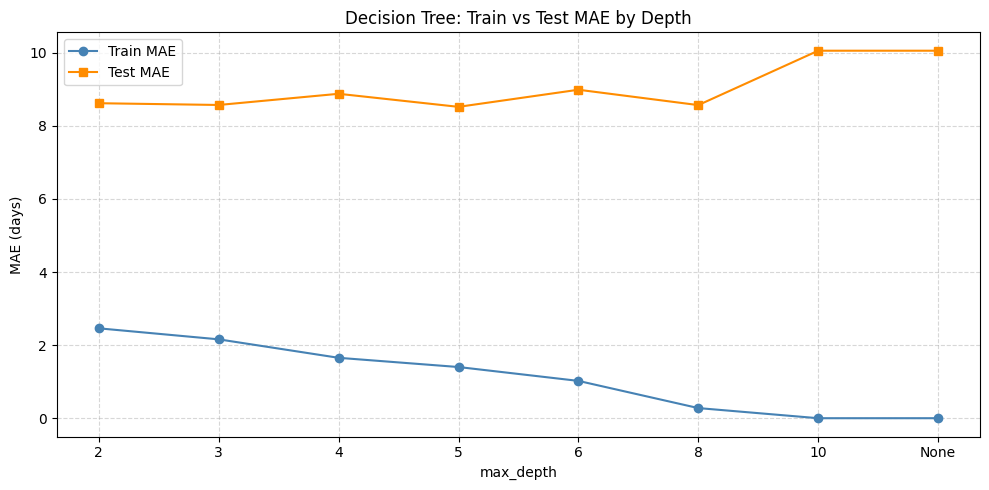

Conclusion: Deep trees overfit. Even shallow trees struggle on this small dataset.


In [3]:
import matplotlib.pyplot as plt
# Learning curve style plot
depths = [2,3,4,5,6,8,10,None]
train_maes, test_maes = [], []
for d in depths:
    dt_d = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_d.fit(X_train, y_train)
    train_maes.append(mean_absolute_error(y_train, dt_d.predict(X_train)))
    test_maes.append(mean_absolute_error(y_test, dt_d.predict(X_test)))

fig, ax = plt.subplots(figsize=(10,5))
labels = [str(d) for d in depths[:-1]] + ['None']
ax.plot(labels, train_maes, 'o-', label='Train MAE', color='steelblue')
ax.plot(labels, test_maes,  's-', label='Test MAE',  color='darkorange')
ax.set_xlabel('max_depth'); ax.set_ylabel('MAE (days)')
ax.set_title('Decision Tree: Train vs Test MAE by Depth')
ax.legend(); ax.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_02_dt_depth.png', dpi=150)
plt.show()
print("Conclusion: Deep trees overfit. Even shallow trees struggle on this small dataset.")


## Overfitting Confirmed
- Best Decision Tree still has large train/test gap
- Even with pruning (min_depth, min_samples), test MAE remains high
- Decision Trees are too sensitive to small sample sizes (n=141)